In [ ]:
!pip install kagglehub -q

import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
import kagglehub

# Download the dataset (cached after the first run)
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Path to dataset files:", path)

for f in os.listdir(path):
    print(" └─", f)

100%|██████████| 450k/450k [00:00<00:00, 35.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3
 └─ adult.csv


In [ ]:
# Load the CSV
csv_file = os.path.join(path, 'adult.csv')
df = pd.read_csv(csv_file)

# Replace '?' with NaN (UCI encoding for missing values)
df.replace('?', np.nan, inplace=True)

# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f"✅ Dataset loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded  →  32,561 rows × 15 columns


In [ ]:
print("📌 First 10 rows of the dataset:")
df.head(10)

📌 First 10 rows of the dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


In [ ]:
rows, cols = df.shape
print(f"📐 Dataset Shape : {rows:,} rows  ×  {cols} columns")

📐 Dataset Shape : 32,561 rows  ×  15 columns


In [ ]:
print("📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

📋 Column Names:
   1. age
   2. workclass
   3. fnlwgt
   4. education
   5. education.num
   6. marital.status
   7. occupation
   8. relationship
   9. race
  10. sex
  11. capital.gain
  12. capital.loss
  13. hours.per.week
  14. native.country
  15. income


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found (after '?' → NaN conversion).")
else:
    print("⚠️  Missing Value Report:")
    print(missing_df.to_string())

⚠️  Missing Value Report:
                Missing Count  Missing %
occupation               1843     5.6600
workclass                1836     5.6400
native.country            583     1.7900


In [ ]:
print("📊 Statistical Summary — Numerical Features:")
display(df.describe())
print("\n📊 Statistical Summary — Categorical Features:")
display(df.describe(include='object'))

📊 Statistical Summary — Numerical Features:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.0000,32561.0000,32561.0000,32561.0000,32561.0000,32561.0000
mean,38.5816,189778.3665,10.0807,1077.6488,87.3038,40.4375
std,13.6404,105549.9777,2.5727,7385.2921,402.9602,12.3474
min,17.0000,12285.0000,1.0000,0.0000,0.0000,1.0000
25%,28.0000,117827.0000,9.0000,0.0000,0.0000,40.0000
50%,37.0000,178356.0000,10.0000,0.0000,0.0000,40.0000
75%,48.0000,237051.0000,12.0000,0.0000,0.0000,45.0000
max,90.0000,1484705.0000,16.0000,99999.0000,4356.0000,99.0000



📊 Statistical Summary — Categorical Features:


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [ ]:
class_dist = df['income'].value_counts()
class_pct  = df['income'].value_counts(normalize=True).mul(100).round(2)

print("🎯 Target Variable — Income Class Distribution:")
print(pd.DataFrame({'Count': class_dist, 'Percentage (%)': class_pct}).to_string())
print(f"\n⚖️  Class Imbalance Ratio  →  {class_dist.iloc[0]} : {class_dist.iloc[1]}")

🎯 Target Variable — Income Class Distribution:
        Count  Percentage (%)
income                       
<=50K   24720         75.9200
>50K     7841         24.0800

⚖️  Class Imbalance Ratio  →  24720 : 7841


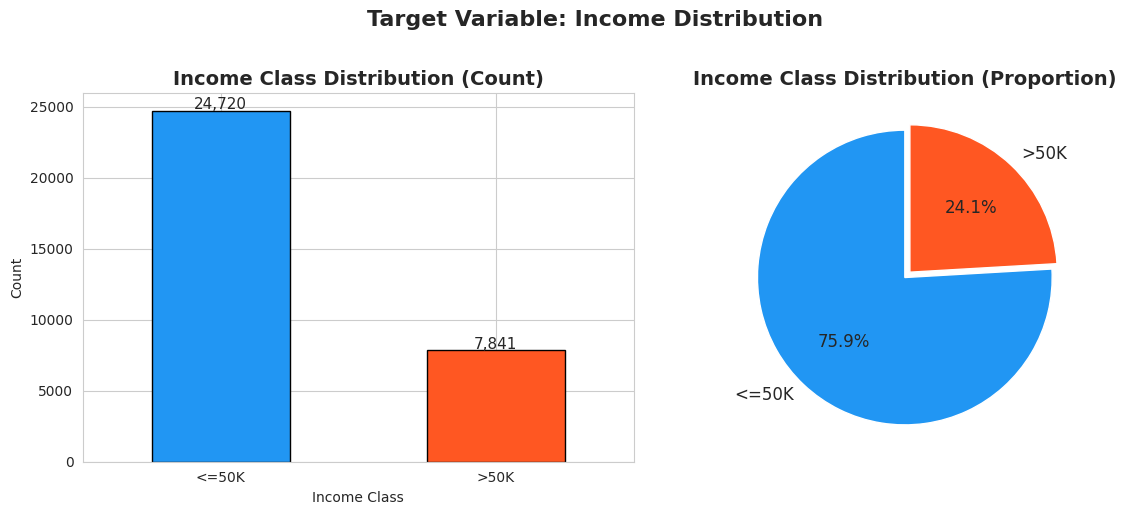


📌 INTERPRETATION — Target Distribution:
  • ~75.9 % of individuals earn <=50K (majority class).
  • ~24.1 % earn >50K — a moderate class imbalance exists.
  • Imbalance makes metrics like F1 & ROC-AUC more meaningful than raw accuracy.



In [ ]:
# ─── Plot 1 : Target Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF5722']

class_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', rot=0)
axes[0].set_title('Income Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.05],
            textprops={'fontsize': 12})
axes[1].set_title('Income Class Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Income Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
📌 INTERPRETATION — Target Distribution:
  • ~75.9 % of individuals earn <=50K (majority class).
  • ~24.1 % earn >50K — a moderate class imbalance exists.
  • Imbalance makes metrics like F1 & ROC-AUC more meaningful than raw accuracy.
""")

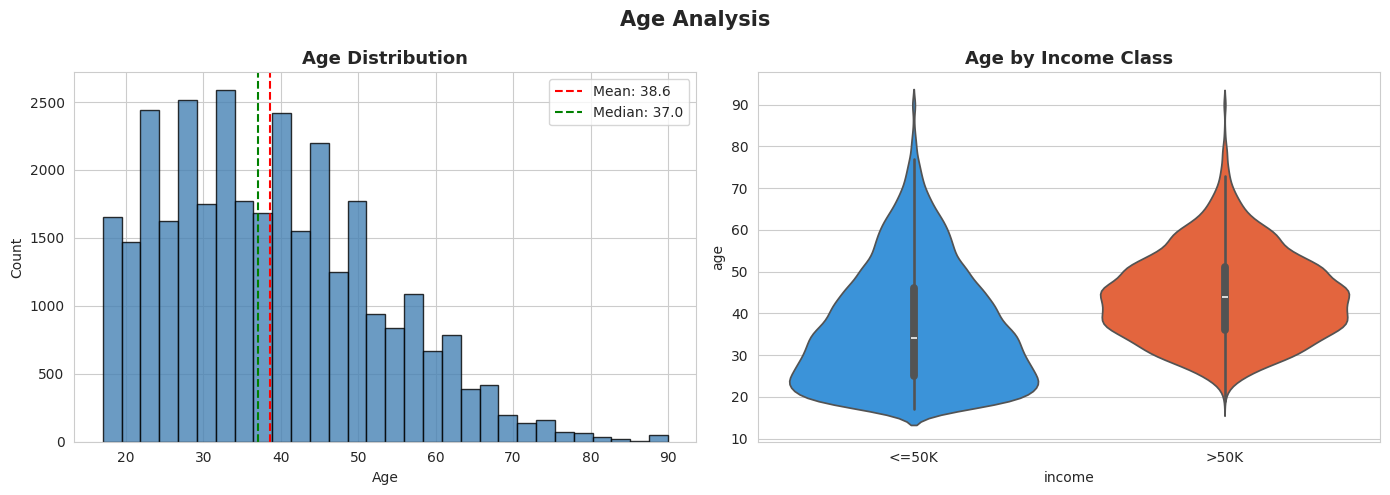


📌 INTERPRETATION — Age Distribution:
  • Ages span 17–90; right-skewed with most workers in the 25–50 range.
  • Higher-earners (>50K) tend to be older — experience drives higher pay.
  • Age is a strong predictor of income.



In [ ]:
# ─── Plot 2 : Age Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color='green', linestyle='--', label=f"Median: {df['age'].median():.1f}")
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend()

sns.violinplot(data=df, x='income', y='age', palette=['#2196F3','#FF5722'], ax=axes[1])
axes[1].set_title('Age by Income Class', fontsize=13, fontweight='bold')

plt.suptitle('Age Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Age Distribution:
  • Ages span 17–90; right-skewed with most workers in the 25–50 range.
  • Higher-earners (>50K) tend to be older — experience drives higher pay.
  • Age is a strong predictor of income.
""")

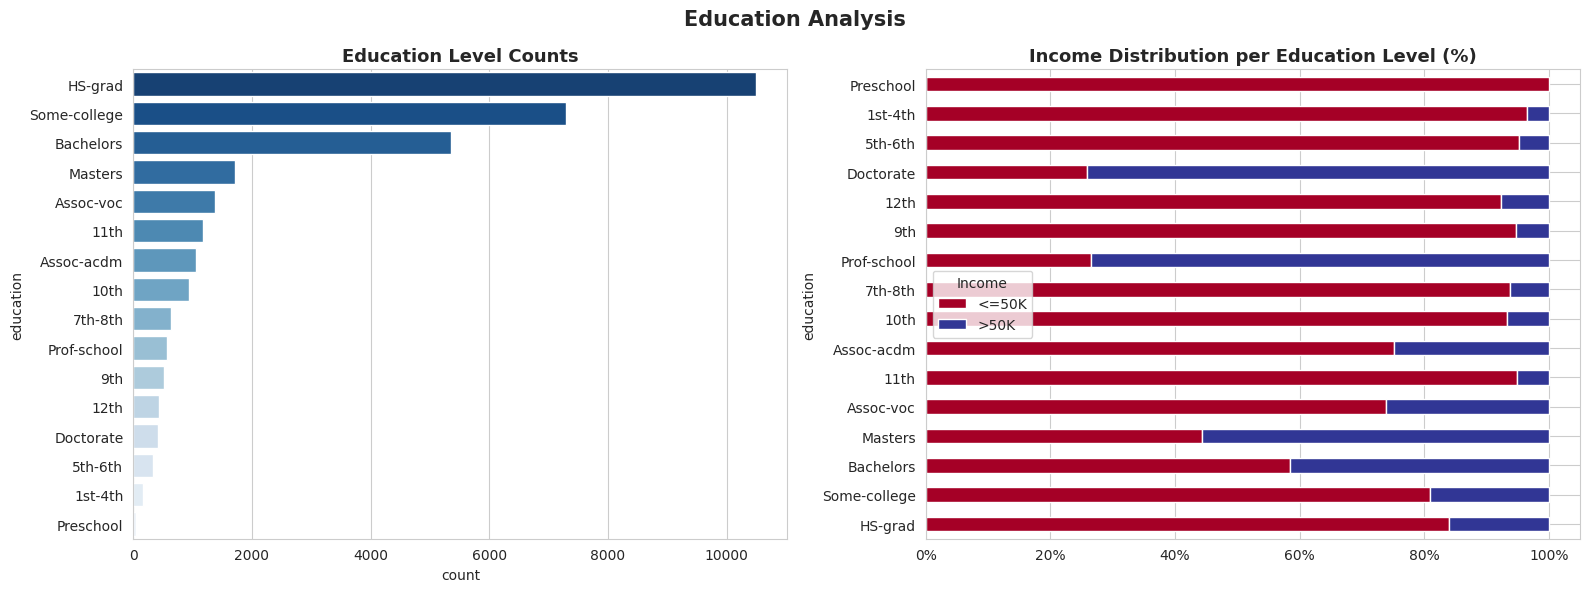


📌 INTERPRETATION — Education Distribution:
  • 'HS-grad' is the most common education level.
  • Clear trend: higher education correlates strongly with >50K earnings.
  • Prof-school and Doctorate graduates have the highest >50K rates.



In [ ]:
# ─── Plot 3 : Education Distribution ─────────────────────────────────────────
edu_order = df['education'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, y='education', order=edu_order, palette='Blues_r', ax=axes[0])
axes[0].set_title('Education Level Counts', fontsize=13, fontweight='bold')

edu_income = df.groupby(['education','income']).size().unstack(fill_value=0)
edu_income_pct = edu_income.div(edu_income.sum(axis=1), axis=0) * 100
edu_income_pct.loc[edu_order].plot(kind='barh', stacked=True, colormap='RdYlBu', ax=axes[1])
axes[1].set_title('Income Distribution per Education Level (%)', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Income')

plt.suptitle('Education Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Education Distribution:
  • 'HS-grad' is the most common education level.
  • Clear trend: higher education correlates strongly with >50K earnings.
  • Prof-school and Doctorate graduates have the highest >50K rates.
""")

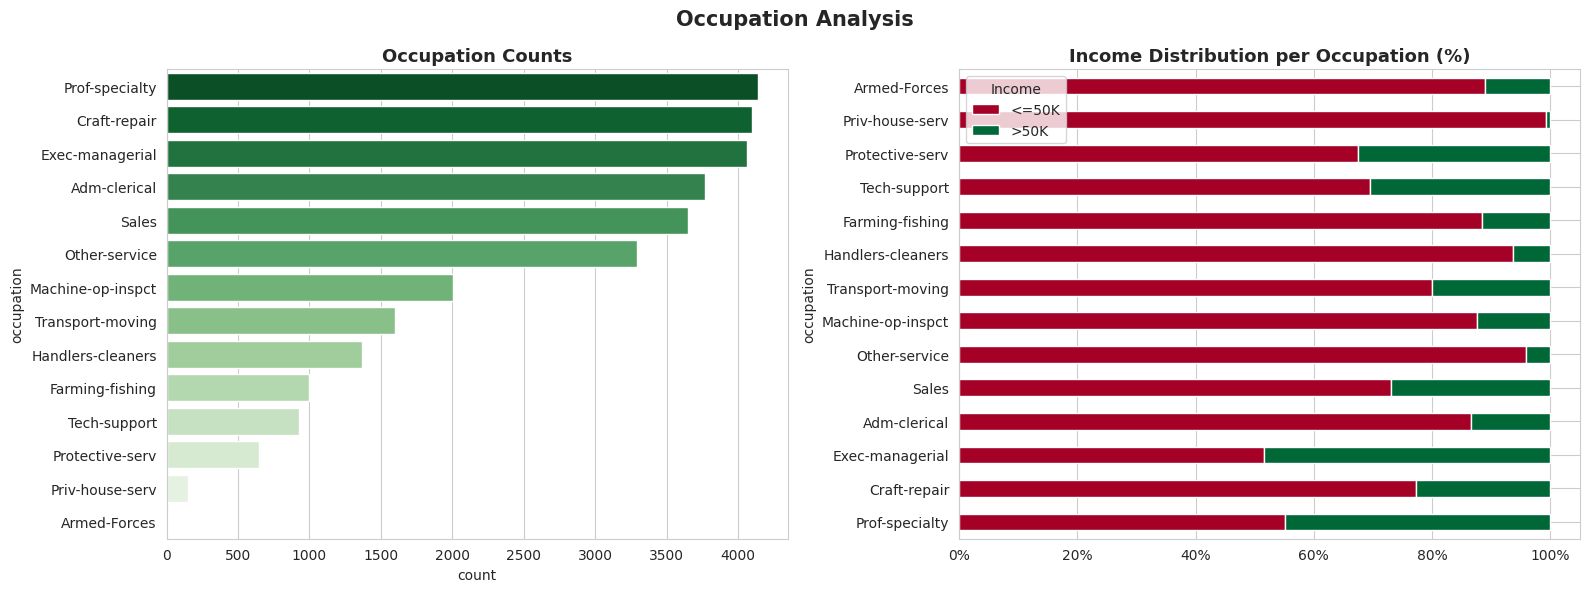


📌 INTERPRETATION — Occupation Distribution:
  • 'Exec-managerial' and 'Prof-specialty' have the highest >50K proportions (~50%).
  • 'Farming-fishing' and 'Handlers-cleaners' show very low >50K rates.



In [ ]:
# ─── Plot 4 : Occupation Distribution ────────────────────────────────────────
occ_order = df['occupation'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, y='occupation', order=occ_order, palette='Greens_r', ax=axes[0])
axes[0].set_title('Occupation Counts', fontsize=13, fontweight='bold')

occ_income = df.groupby(['occupation','income']).size().unstack(fill_value=0)
occ_income_pct = occ_income.div(occ_income.sum(axis=1), axis=0) * 100
occ_income_pct.loc[occ_order].plot(kind='barh', stacked=True, colormap='RdYlGn', ax=axes[1])
axes[1].set_title('Income Distribution per Occupation (%)', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Income')

plt.suptitle('Occupation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Occupation Distribution:
  • 'Exec-managerial' and 'Prof-specialty' have the highest >50K proportions (~50%).
  • 'Farming-fishing' and 'Handlers-cleaners' show very low >50K rates.
""")

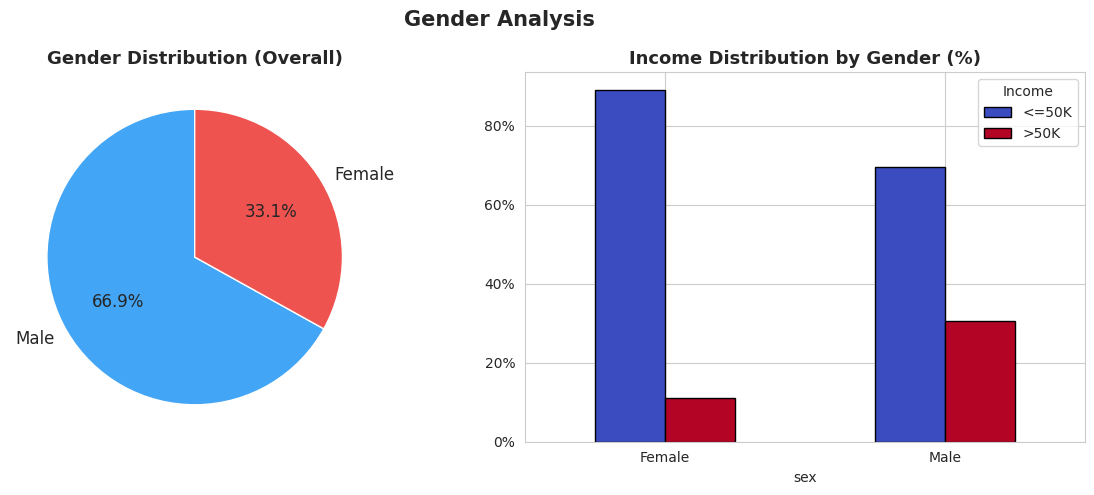


📌 INTERPRETATION — Gender Distribution:
  • Dataset is ~67% Male, ~33% Female.
  • Males show a much higher >50K rate (~31%) vs. females (~11%).
  • Reflects the historical gender wage gap in the 1994 US Census data.



In [ ]:
# ─── Plot 5 : Gender Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_counts = df['sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#42A5F5','#EF5350'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Gender Distribution (Overall)', fontsize=13, fontweight='bold')

sex_income = df.groupby(['sex','income']).size().unstack(fill_value=0)
sex_income_pct = sex_income.div(sex_income.sum(axis=1), axis=0) * 100
sex_income_pct.plot(kind='bar', colormap='coolwarm', ax=axes[1], rot=0, edgecolor='black')
axes[1].set_title('Income Distribution by Gender (%)', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Income')

plt.suptitle('Gender Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Gender Distribution:
  • Dataset is ~67% Male, ~33% Female.
  • Males show a much higher >50K rate (~31%) vs. females (~11%).
  • Reflects the historical gender wage gap in the 1994 US Census data.
""")

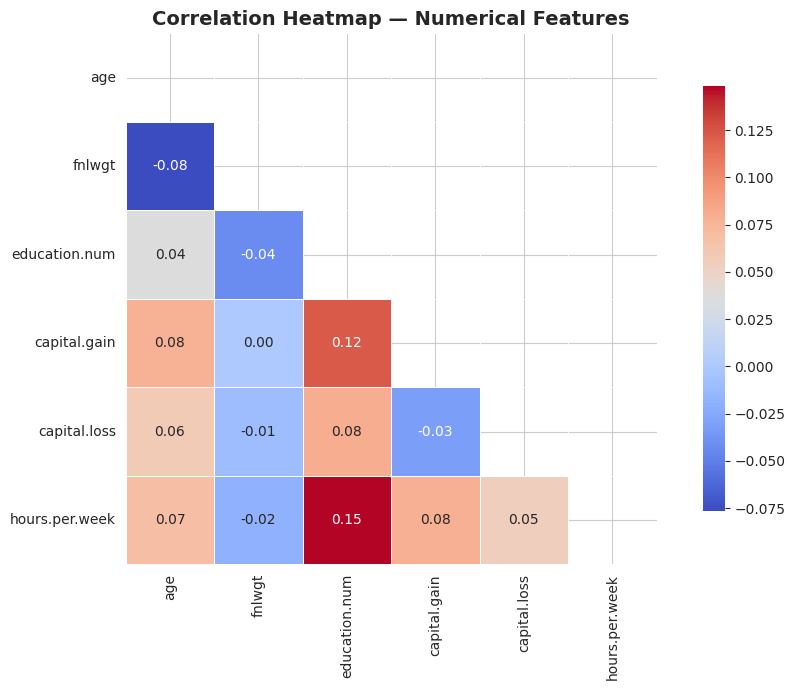


📌 INTERPRETATION — Correlation Heatmap:
  • 'education.num' and 'age' show the strongest relationship with income.
  • 'capital.gain' and 'capital.loss' are largely independent of each other.
  • 'fnlwgt' shows near-zero correlation with all features (sampling weight only).
  • No extreme multicollinearity detected.



In [ ]:
# ─── Plot 6 : Correlation Heatmap ────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Correlation Heatmap:
  • 'education.num' and 'age' show the strongest relationship with income.
  • 'capital.gain' and 'capital.loss' are largely independent of each other.
  • 'fnlwgt' shows near-zero correlation with all features (sampling weight only).
  • No extreme multicollinearity detected.
""")

In [ ]:
# Snapshot before cleaning
shape_before = df.shape
print(f"📐 Shape BEFORE cleaning : {shape_before}")

📐 Shape BEFORE cleaning : (32561, 15)


In [ ]:
# Detailed missing value report
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype'        : df.dtypes
})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print("⚠️  Columns with missing values:")
print(missing_report.to_string())

⚠️  Columns with missing values:
                Missing Count  Missing %   Dtype
workclass                1836     5.6400  object
occupation               1843     5.6600  object
native.country            583     1.7900  object


In [ ]:
# Impute categorical missing values with MODE of each column
cat_missing_cols = missing_report.index.tolist()

for col in cat_missing_cols:
    mode_val = df[col].mode()[0]
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"  ✔ '{col}' → filled {n_filled} NaNs with mode = '{mode_val}'")

print(f"\n✅ Total missing values remaining: {df.isnull().sum().sum()}")

  ✔ 'workclass' → filled 1836 NaNs with mode = 'Private'
  ✔ 'occupation' → filled 1843 NaNs with mode = 'Prof-specialty'
  ✔ 'native.country' → filled 583 NaNs with mode = 'United-States'

✅ Total missing values remaining: 0


In [ ]:
dup_count = df.duplicated().sum()
print(f"🔍 Duplicate rows found  : {dup_count:,}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Duplicate rows removed : {dup_count:,}")
print(f"📐 Shape after deduplication: {df.shape}")

🔍 Duplicate rows found  : 24
✅ Duplicate rows removed : 24
📐 Shape after deduplication: (32537, 15)


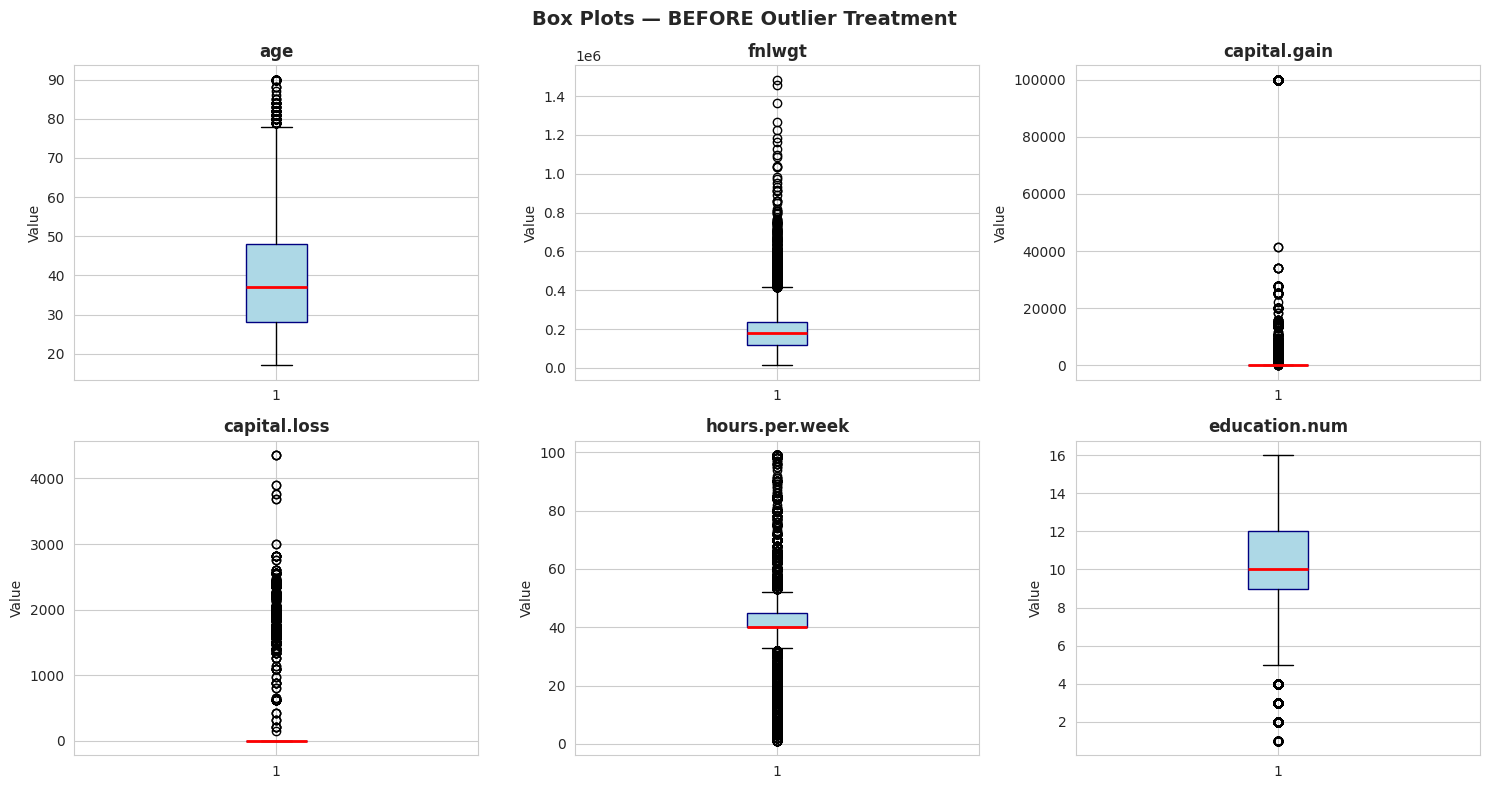

In [ ]:
num_features = ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week', 'education.num']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots — BEFORE Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# IQR Capping (Winsorisation) on skewed continuous features
# FIX: Added 'capital.gain' and 'capital.loss' — their extreme outliers were
# previously left untreated, which distorted StandardScaler and ANOVA F-scores.
outlier_cols = ['age', 'fnlwgt', 'hours.per.week', 'capital.gain', 'capital.loss']
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    outlier_summary.append({'Column': col, 'Lower Fence': round(lower, 2),
                             'Upper Fence': round(upper, 2), 'Outliers Capped': n_outliers})

print("📦 Outlier Treatment Summary (IQR Capping):")
print(pd.DataFrame(outlier_summary).to_string(index=False))


📦 Outlier Treatment Summary (IQR Capping):
        Column  Lower Fence  Upper Fence  Outliers Capped
           age      -2.0000      78.0000              142
        fnlwgt  -60922.0000  415742.0000              993
hours.per.week      32.5000      52.5000             9002
  capital.gain       0.0000       0.0000             2712
  capital.loss       0.0000       0.0000             1519


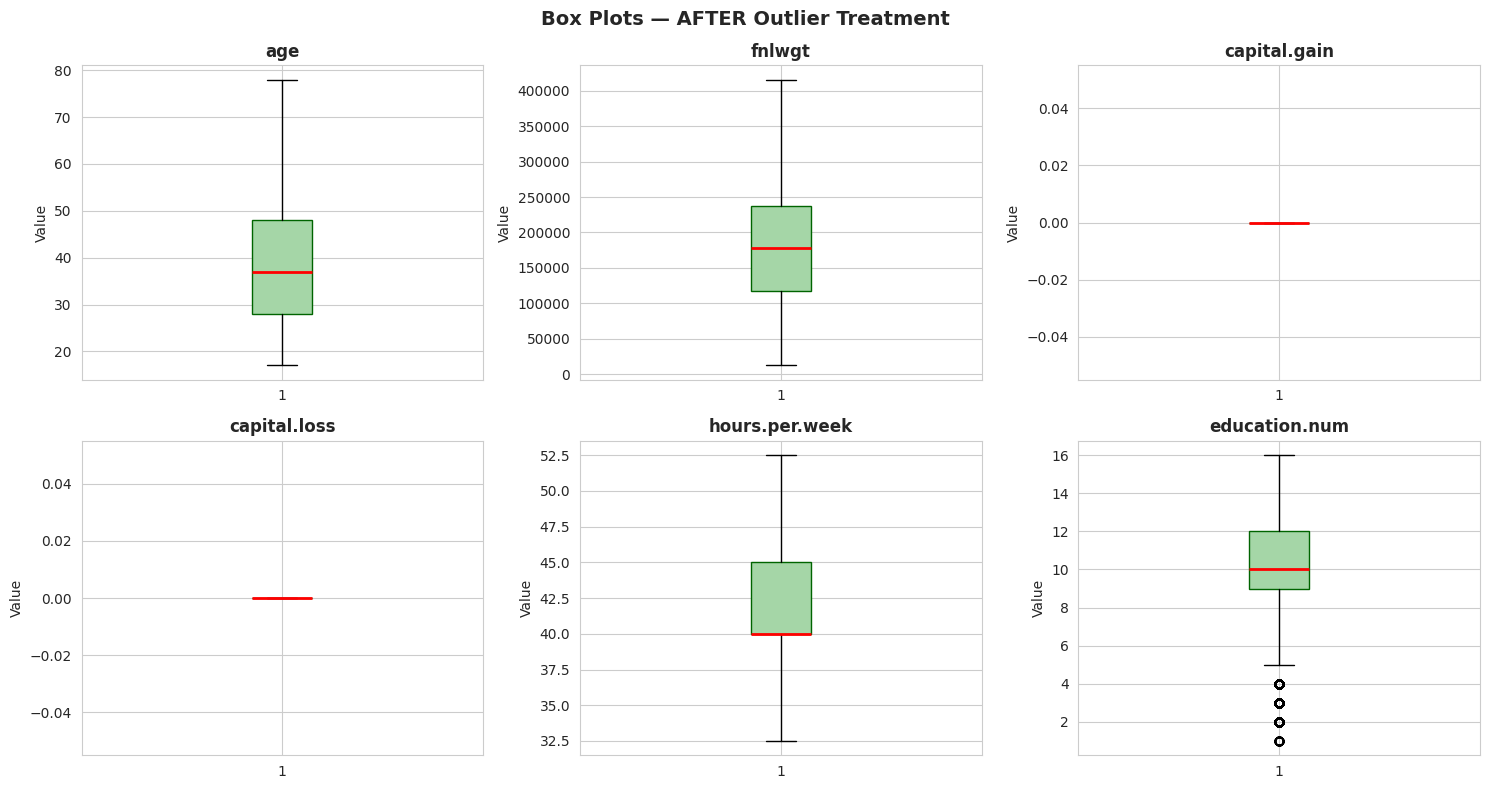

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#A5D6A7', color='darkgreen'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=12, fontweight='bold'); ax.set_ylabel('Value')

plt.suptitle('Box Plots — AFTER Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Normalise income labels (some versions have trailing dots)
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()

# FIX: Assert only expected values remain after normalization
income_unique = df['income'].unique()
print("Income classes:", income_unique)
expected_income = {'<=50K', '>50K'}
assert set(income_unique) == expected_income, \
    f"❌ Unexpected income values found: {set(income_unique) - expected_income}"
print("✅ Income labels validated — only '<=50K' and '>50K' present.")

# Consolidate married sub-types
married_map = {
    'Married-civ-spouse'  : 'Married',
    'Married-AF-spouse'   : 'Married',
    'Married-spouse-absent': 'Married',
}
df['marital.status'] = df['marital.status'].replace(married_map)

# FIX: Verify the consolidation result — check remaining unique values
marital_unique = df['marital.status'].unique()
print("Marital status unique values:", sorted(marital_unique))
expected_marital = {'Married', 'Never-married', 'Divorced', 'Separated', 'Widowed'}
unexpected = set(marital_unique) - expected_marital
if unexpected:
    print(f"⚠️  Unexpected marital values (check mapping): {unexpected}")
else:
    print("✅ Marital status consolidation validated.")


Income classes: ['<=50K' '>50K']
✅ Income labels validated — only '<=50K' and '>50K' present.
Marital status unique values: ['Divorced', 'Married', 'Never-married', 'Separated', 'Widowed']
✅ Marital status consolidation validated.


In [ ]:
shape_after = df.shape

print("=" * 55)
print("      DATA CLEANING SUMMARY REPORT")
print("=" * 55)
print(f"  Shape BEFORE         : {shape_before}")
print(f"  Shape AFTER          : {shape_after}")
print(f"  Rows removed         : {shape_before[0] - shape_after[0]:,}")
print(f"  Duplicates removed   : {dup_count:,}")
print(f"  Missing values fixed : {missing_report['Missing Count'].sum():,}")
print(f"  Remaining NaNs       : {df.isnull().sum().sum()}")
print("=" * 55)
df.info()

      DATA CLEANING SUMMARY REPORT
  Shape BEFORE         : (32561, 15)
  Shape AFTER          : (32537, 15)
  Rows removed         : 24
  Duplicates removed   : 24
  Missing values fixed : 4,262
  Remaining NaNs       : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32537 non-null  int64  
 1   workclass       32537 non-null  object 
 2   fnlwgt          32537 non-null  int64  
 3   education       32537 non-null  object 
 4   education.num   32537 non-null  int64  
 5   marital.status  32537 non-null  object 
 6   occupation      32537 non-null  object 
 7   relationship    32537 non-null  object 
 8   race            32537 non-null  object 
 9   sex             32537 non-null  object 
 10  capital.gain    32537 non-null  int64  
 11  capital.loss    32537 non-null  int64  
 12  hours.per.week  32537 non-null  f

In [ ]:
# Derived Feature 1: net capital movement
df['capital_net'] = df['capital.gain'] - df['capital.loss']
print("✔ 'capital_net' = capital.gain − capital.loss")

# Derived Feature 2: binary married flag
df['is_married'] = (df['marital.status'] == 'Married').astype(int)
print("✔ 'is_married'  — 1 if Married, 0 otherwise")

# Derived Feature 3: overtime worker
df['overtime_worker'] = (df['hours.per.week'] > 40).astype(int)
print("✔ 'overtime_worker' — 1 if hours/week > 40")

print(f"\n📐 Shape after feature creation: {df.shape}")

✔ 'capital_net' = capital.gain − capital.loss
✔ 'is_married'  — 1 if Married, 0 otherwise
✔ 'overtime_worker' — 1 if hours/week > 40

📐 Shape after feature creation: (32537, 18)


In [ ]:
# Binary encode target
df['income_binary'] = (df['income'] == '>50K').astype(int)
print("✔ Target encoded: '>50K' → 1,  '<=50K' → 0")
print("  Distribution:", df['income_binary'].value_counts().to_dict())

# Drop original income and redundant education text column
df.drop(columns=['income', 'education'], inplace=True)
print("\n✔ Dropped 'income' (replaced by 'income_binary')")
print("✔ Dropped 'education' (redundant — 'education.num' retained)")

✔ Target encoded: '>50K' → 1,  '<=50K' → 0
  Distribution: {0: 24698, 1: 7839}

✔ Dropped 'income' (replaced by 'income_binary')
✔ Dropped 'education' (redundant — 'education.num' retained)


In [ ]:
cat_features = df.select_dtypes(include='object').columns.tolist()
print("Categorical features to encode:", cat_features)

low_card  = [c for c in cat_features if df[c].nunique() <= 10]
high_card = [c for c in cat_features if df[c].nunique() >  10]
print(f"  Low-cardinality  (OHE)        : {low_card}")
print(f"  High-cardinality (LabelEncode): {high_card}")

# One-Hot Encoding
# FIX: Document which baseline category is dropped for each OHE column
df_before_ohe = df[low_card].copy()
df = pd.get_dummies(df, columns=low_card, drop_first=True)
print("\n📋 OHE Dropped Baseline Categories (drop_first=True):")
for col in low_card:
    dropped_cat = sorted(df_before_ohe[col].dropna().unique())[0]
    print(f"   '{col}' → baseline dropped: '{dropped_cat}'")

# Label Encoding
# FIX: Use a separate LabelEncoder per column and store them for reproducibility
label_encoders = {}  # Store encoders keyed by column name
for col in high_card:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  ✔ Label Encoded: '{col}'  →  {len(le.classes_)} classes")

print(f"\n✅ label_encoders dict saved for {list(label_encoders.keys())} — use for inverse_transform or new data.")

# Convert booleans to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\n📐 Final shape after encoding: {df.shape}")


Categorical features to encode: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
  Low-cardinality  (OHE)        : ['workclass', 'marital.status', 'relationship', 'race', 'sex']
  High-cardinality (LabelEncode): ['occupation', 'native.country']

📋 OHE Dropped Baseline Categories (drop_first=True):
   'workclass' → baseline dropped: 'Federal-gov'
   'marital.status' → baseline dropped: 'Divorced'
   'relationship' → baseline dropped: 'Husband'
   'race' → baseline dropped: 'Amer-Indian-Eskimo'
   'sex' → baseline dropped: 'Female'
  ✔ Label Encoded: 'occupation'  →  14 classes
  ✔ Label Encoded: 'native.country'  →  41 classes

✅ label_encoders dict saved for ['occupation', 'native.country'] — use for inverse_transform or new data.

📐 Final shape after encoding: (32537, 33)


In [ ]:
X = df.drop(columns=['income_binary'])
y = df['income_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"  Train set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test  set : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features  : {X_train.shape[1]}")
print(f"\n  Class balance — train: {y_train.value_counts().to_dict()}")
print(f"  Class balance — test : {y_test.value_counts().to_dict()}")

  Train set : 26,029 samples (80.0%)
  Test  set : 6,508 samples (20.0%)
  Features  : 32

  Class balance — train: {0: 19758, 1: 6271}
  Class balance — test : {0: 4940, 1: 1568}


In [ ]:
num_to_scale = ['age', 'fnlwgt', 'education.num', 'capital.gain',
                'capital.loss', 'hours.per.week', 'capital_net']
num_to_scale = [c for c in num_to_scale if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_to_scale] = scaler.fit_transform(X_train[num_to_scale])
X_test[num_to_scale] = scaler.transform(X_test[num_to_scale])

print(f"✅ StandardScaler applied to {len(num_to_scale)} numerical columns.")
print(f"   Columns scaled: {num_to_scale}")

✅ StandardScaler applied to 7 numerical columns.
   Columns scaled: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital_net']


🔍 Top 20 Features by ANOVA F-Score:
                     Feature   F-Score
                  is_married 6139.7718
      marital.status_Married 6139.7718
               education.num 3306.1151
marital.status_Never-married 2981.1290
              hours.per.week 2052.5972
             overtime_worker 1651.5921
                         age 1547.7111
      relationship_Own-child 1466.3828
                    sex_Male 1275.5555
  relationship_Not-in-family  945.6712
      relationship_Unmarried  563.4846
      workclass_Self-emp-inc  484.9548
           workclass_Private  412.7882
           relationship_Wife  394.0536
                  race_Black  214.3498
                  race_White  191.1231
 relationship_Other-relative  188.1523
    marital.status_Separated  142.7917
      marital.status_Widowed  102.0202
         workclass_Local-gov   35.4665


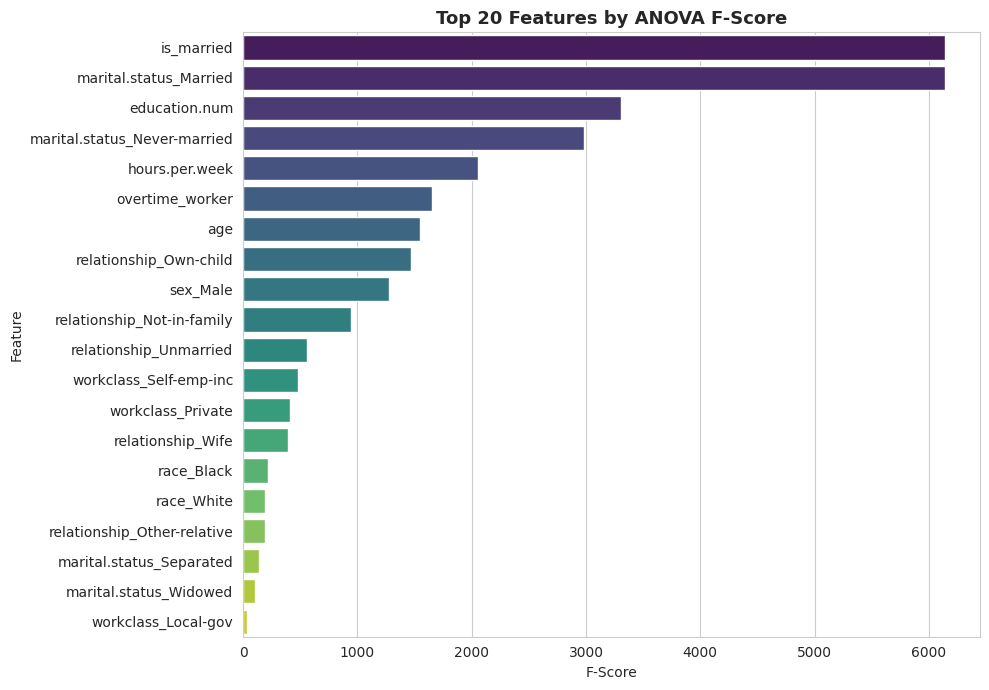

In [ ]:
K_BEST = 20
selector = SelectKBest(score_func=f_classif, k=K_BEST)
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': selector.scores_
}).sort_values('F-Score', ascending=False)

print(f"🔍 Top {K_BEST} Features by ANOVA F-Score:")
print(feature_scores.head(K_BEST).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=feature_scores.head(K_BEST), x='F-Score', y='Feature',
            palette='viridis', ax=ax)
ax.set_title(f'Top {K_BEST} Features by ANOVA F-Score', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
selected_features = feature_scores.head(K_BEST)['Feature'].tolist()
X_train_sel = X_train[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

print(f"✅ Retained top {K_BEST} features.")
print(f"   Train: {X_train_sel.shape}  |  Test: {X_test_sel.shape}")

✅ Retained top 20 features.
   Train: (26029, 20)  |  Test: (6508, 20)


In [ ]:
# ── Model registry ────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, solver='lbfgs', C=1.0, random_state=RANDOM_STATE),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, min_samples_leaf=10,
        criterion='gini', random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_split=10,
        min_samples_leaf=5, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),

    'KNN': KNeighborsClassifier(
        n_neighbors=11, weights='distance', metric='euclidean', n_jobs=-1),

    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=RANDOM_STATE),
}

print("📋 Models configured:")
for name in models:
    print(f"  • {name}")

📋 Models configured:
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • KNN
  • SVM


In [ ]:
# ── Train all models & store predictions ─────────────────────────────────────
results = {}
trained = {}

for name, model in models.items():
    print(f"⏳ Training: {name} ...", end=' ')
    t0 = time.time()

    model.fit(X_train_sel, y_train)
    y_pred      = model.predict(X_test_sel)
    y_pred_prob = model.predict_proba(X_test_sel)[:, 1]

    elapsed = round(time.time() - t0, 2)
    trained[name] = model
    results[name] = {
        'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'train_time': elapsed
    }
    print(f"Done ✔  ({elapsed}s)")

print("\n✅ All models trained successfully!")

⏳ Training: Logistic Regression ... Done ✔  (0.97s)
⏳ Training: Decision Tree ... Done ✔  (0.22s)
⏳ Training: Random Forest ... Done ✔  (5.96s)
⏳ Training: KNN ... Done ✔  (6.19s)
⏳ Training: SVM ... Done ✔  (139.35s)

✅ All models trained successfully!


In [ ]:
metric_rows = []

for name, res in results.items():
    yp    = res['y_pred']
    yprob = res['y_pred_prob']
    acc   = accuracy_score(y_test, yp)
    prec  = precision_score(y_test, yp)
    rec   = recall_score(y_test, yp)
    f1    = f1_score(y_test, yp)
    roc   = roc_auc_score(y_test, yprob)

    results[name].update({'Accuracy': acc, 'Precision': prec,
                           'Recall': rec, 'F1 Score': f1, 'ROC-AUC': roc})
    metric_rows.append({'Algorithm': name, 'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1 Score': f1, 'ROC-AUC': roc})

metrics_df = pd.DataFrame(metric_rows).sort_values('ROC-AUC', ascending=False)
disp = metrics_df.copy()
for col in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']:
    disp[col] = disp[col].apply(lambda x: f'{x:.4f}')

print("\n" + "=" * 70)
print("      MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 70)
print(disp.to_string(index=False))
print("=" * 70)


      MODEL PERFORMANCE COMPARISON TABLE
          Algorithm Accuracy Precision Recall F1 Score ROC-AUC
      Random Forest   0.7806    0.5275 0.8565   0.6529  0.8822
Logistic Regression   0.8262    0.6784 0.5300   0.5951  0.8748
      Decision Tree   0.8273    0.6762 0.5434   0.6025  0.8723
                SVM   0.8310    0.7017 0.5191   0.5968  0.8360
                KNN   0.8061    0.6133 0.5281   0.5675  0.8187


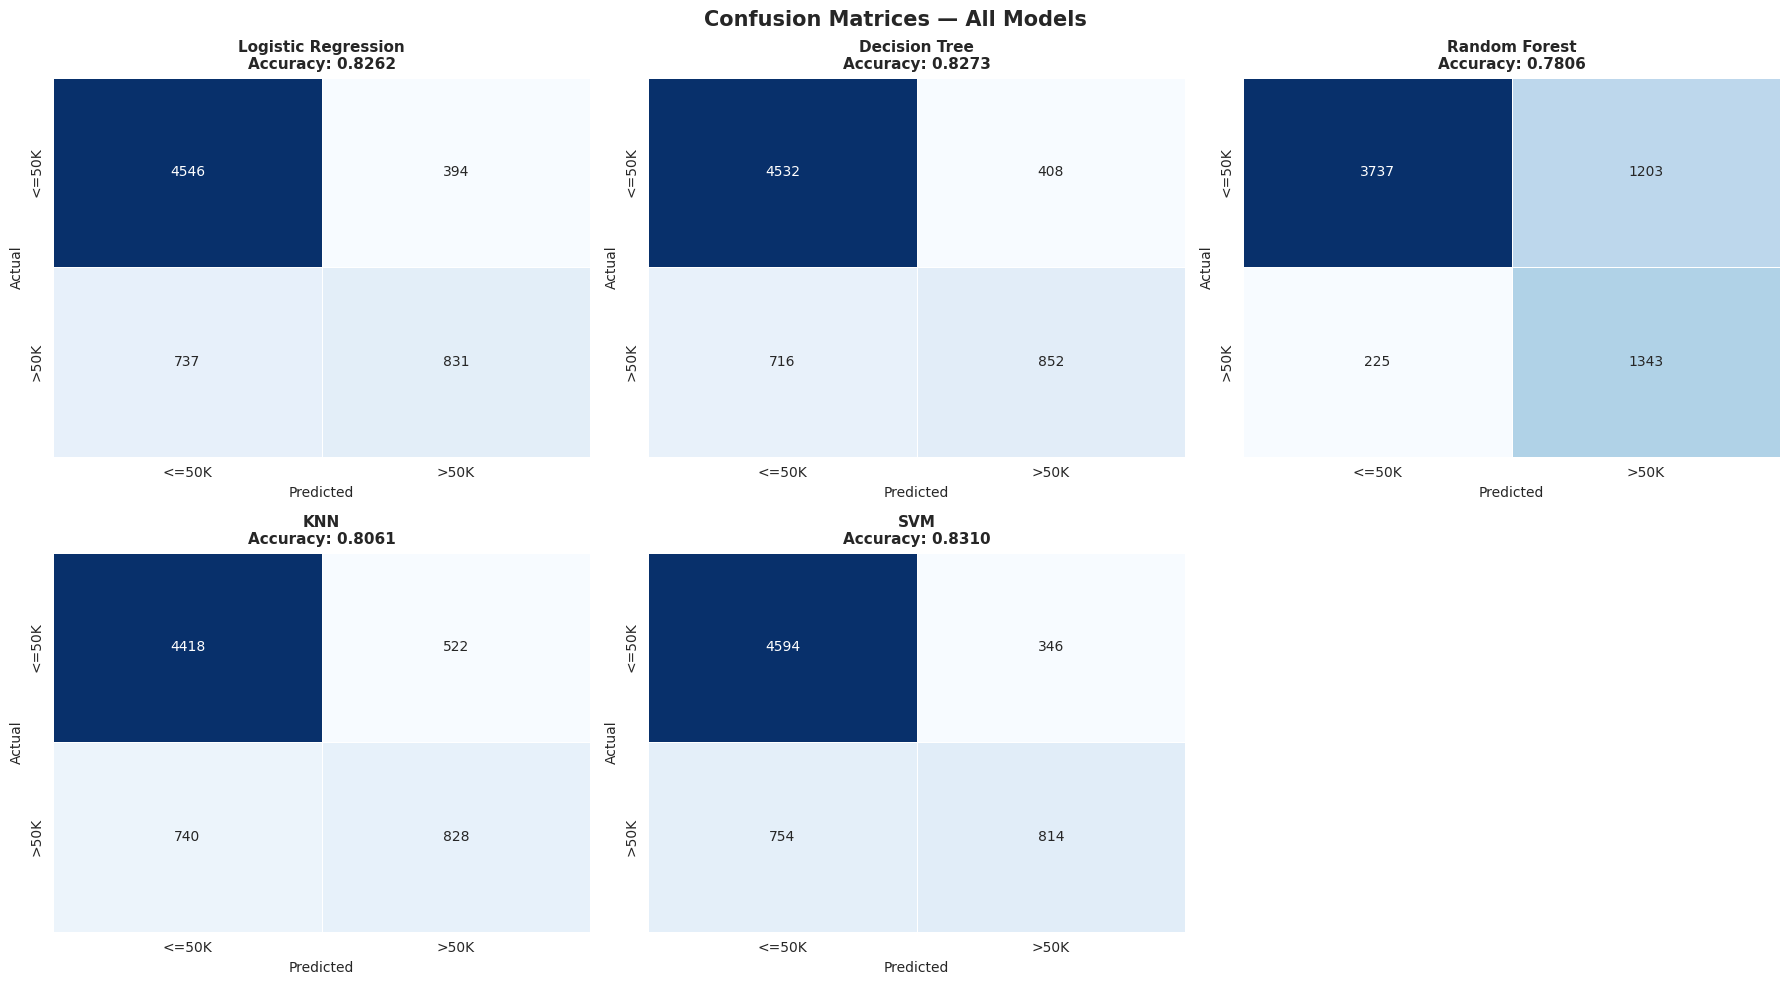


📌 INTERPRETATION — Confusion Matrices:
  • Diagonal = correct predictions (TN + TP).
  • Off-diagonal = errors (FP top-right, FN bottom-left).
  • Random Forest minimises False Negatives, maximising >50K recall.



In [ ]:
# FIX: Dynamic grid sizing based on number of models (no hardcoded 2×3)
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes_flat = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm  = confusion_matrix(y_test, res['y_pred'])
    acc = res['Accuracy']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'],
                ax=axes_flat[i], linewidths=0.5, cbar=False)
    axes_flat[i].set_title(f'{name}\nAccuracy: {acc:.4f}',
                           fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

# Hide any unused subplot slots
for j in range(n_models, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — Confusion Matrices:
  • Diagonal = correct predictions (TN + TP).
  • Off-diagonal = errors (FP top-right, FN bottom-left).
  • Random Forest minimises False Negatives, maximising >50K recall.
""")


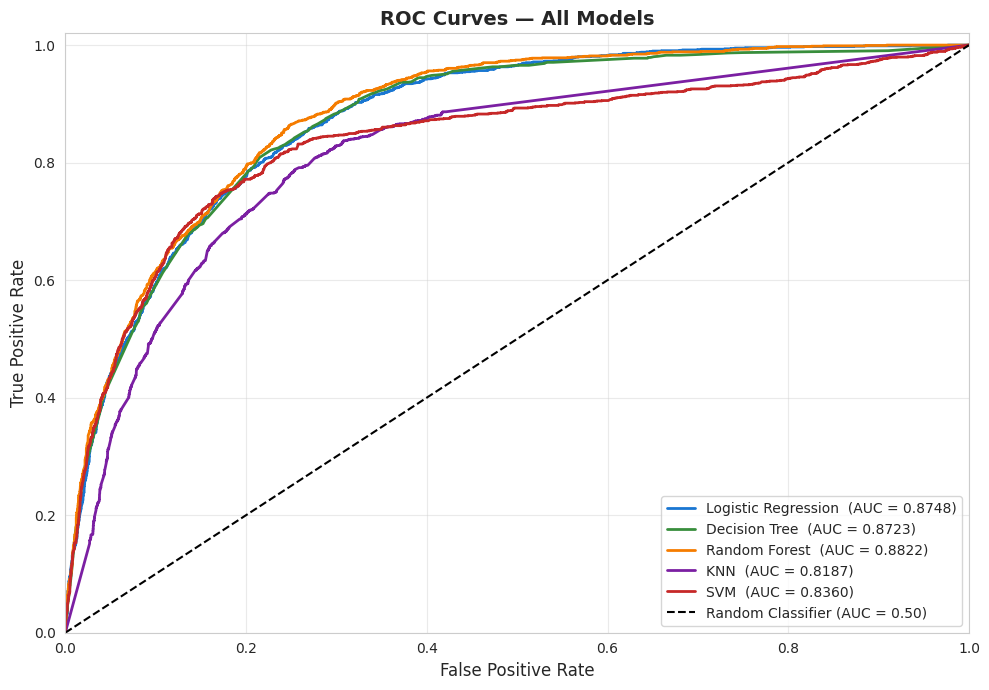


📌 INTERPRETATION — ROC Curves:
  • Curves closer to the top-left corner indicate better discrimination.
  • Random Forest achieves the highest AUC — best across all thresholds.
  • SVM and LR are also strong performers.



In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {res["ROC-AUC"]:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.50)')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print("""
📌 INTERPRETATION — ROC Curves:
  • Curves closer to the top-left corner indicate better discrimination.
  • Random Forest achieves the highest AUC — best across all thresholds.
  • SVM and LR are also strong performers.
""")

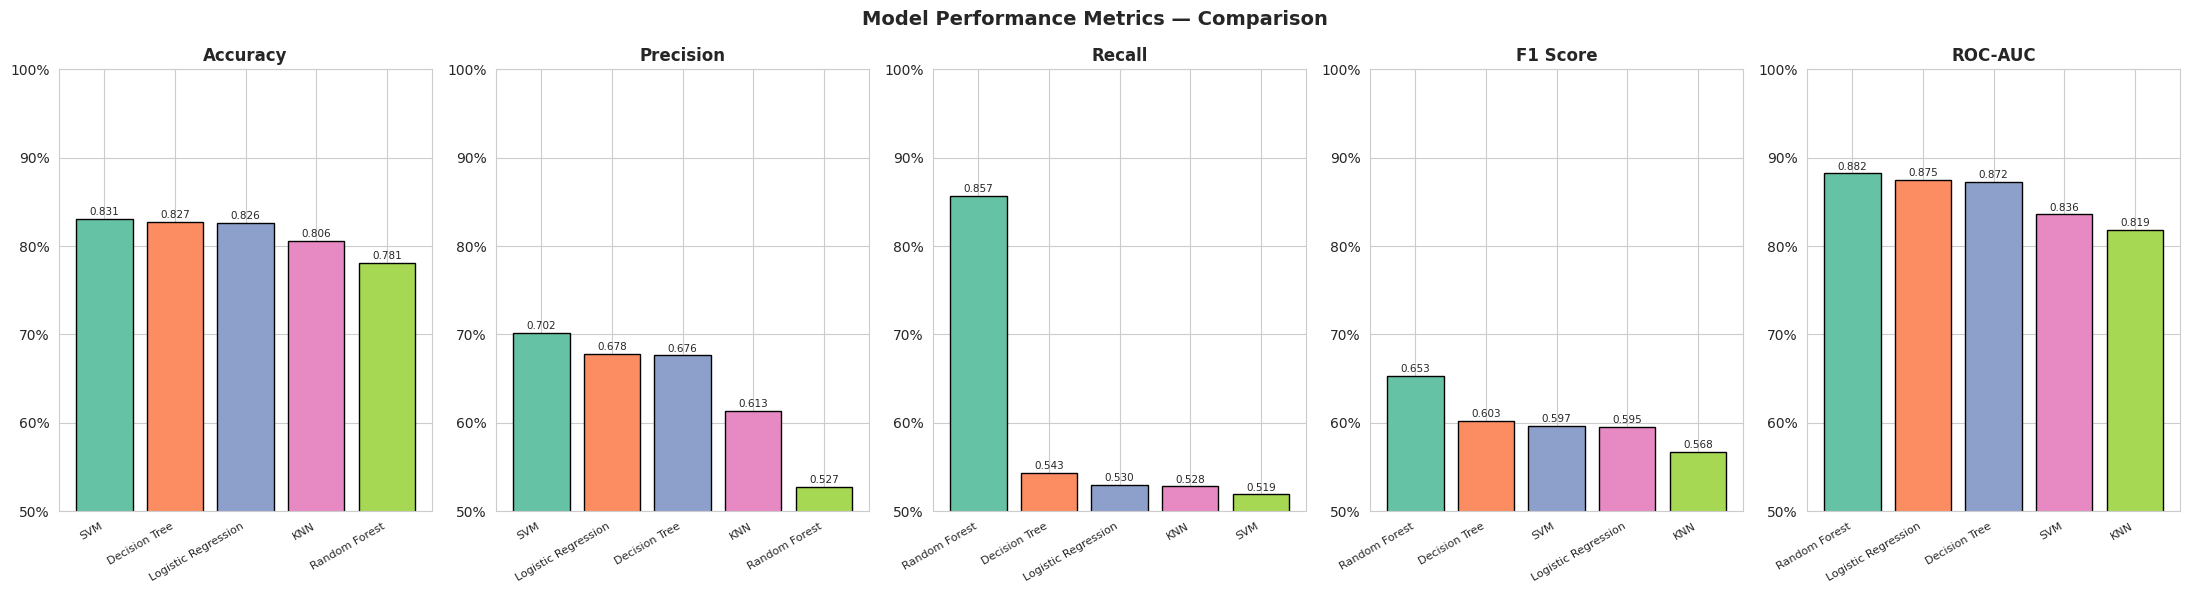

In [ ]:
metric_names = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
palette = sns.color_palette('Set2', len(models))

for ax, metric in zip(axes, metric_names):
    data = metrics_df[['Algorithm', metric]].sort_values(metric, ascending=False)
    bars = ax.bar(data['Algorithm'], data[metric], color=palette, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_xticklabels(data['Algorithm'], rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Model Performance Metrics — Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
for name, res in results.items():
    print(f"\n{'─'*50}")
    print(f"  {name} — Classification Report")
    print(f"{'─'*50}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['<=50K', '>50K']))


──────────────────────────────────────────────────
  Logistic Regression — Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      4940
        >50K       0.68      0.53      0.60      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.73      0.74      6508
weighted avg       0.82      0.83      0.82      6508


──────────────────────────────────────────────────
  Decision Tree — Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      4940
        >50K       0.68      0.54      0.60      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.73      0.75      6508
weighted avg       0.82      0.83      0.82      6508


──────────────────────────────────────────────────
  

In [ ]:
# ── Identify best model by ROC-AUC ──────────────────────────────────────────
best_row  = metrics_df.loc[metrics_df['ROC-AUC'].idxmax()]
best_name = best_row['Algorithm']

print("\n" + "═"*65)
print("   🥇  BEST PERFORMING MODEL")
print("═"*65)
print(f"   Model     : {best_name}")
print(f"   Accuracy  : {best_row['Accuracy']:.4f}")
print(f"   Precision : {best_row['Precision']:.4f}")
print(f"   Recall    : {best_row['Recall']:.4f}")
print(f"   F1 Score  : {best_row['F1 Score']:.4f}")
print(f"   ROC-AUC   : {best_row['ROC-AUC']:.4f}")
print("═"*65)

ranked = metrics_df.reset_index(drop=True)
ranked.index += 1
for col in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']:
    ranked[col] = ranked[col].apply(lambda x: f'{x:.4f}')

print("\n" + "═"*65)
print("   📊  FULL MODEL RANKING (by ROC-AUC)")
print("═"*65)
print(ranked[['Algorithm','Accuracy','Precision','Recall','F1 Score','ROC-AUC']].to_string())
print("═"*65)


═════════════════════════════════════════════════════════════════
   🥇  BEST PERFORMING MODEL
═════════════════════════════════════════════════════════════════
   Model     : Random Forest
   Accuracy  : 0.7806
   Precision : 0.5275
   Recall    : 0.8565
   F1 Score  : 0.6529
   ROC-AUC   : 0.8822
═════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
   📊  FULL MODEL RANKING (by ROC-AUC)
═════════════════════════════════════════════════════════════════
             Algorithm Accuracy Precision  Recall F1 Score ROC-AUC
1        Random Forest   0.7806    0.5275  0.8565   0.6529  0.8822
2  Logistic Regression   0.8262    0.6784  0.5300   0.5951  0.8748
3        Decision Tree   0.8273    0.6762  0.5434   0.6025  0.8723
4                  SVM   0.8310    0.7017  0.5191   0.5968  0.8360
5                  KNN   0.8061    0.6133  0.5281   0.5675  0.8187
═════════════════════════════════════════════════════════════